In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The import statement below is specific so it will need to be changed if anyone wants to run this notebook by themselves, but since this is likely going into a broader script, the functions are the main takeaway. 

In [2]:
# import dataset
soil = pd.read_csv('/Users/hannahperez/Downloads/Station1_raw_merged.csv')

### Sanity Checks

In [4]:
soil.head()

,Unnamed: 0,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.0,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.0,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.0,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.0,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.0,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [5]:
soil.rename(columns = {'Unnamed: 0': 'Date'}, inplace = True)
soil['Date'] = pd.to_datetime(soil['Date'])
soil.head()

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.0,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.0,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.0,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.0,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.0,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [6]:
soil.tail()

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
57906,2021-08-31 20:00:00,0.0,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,0.0,29.10,60.19,0.610,197.1,0.0,30.3989,-98.6105
57907,2021-08-31 21:00:00,0.0,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,0.0,28.07,62.28,0.510,199.6,0.0,30.3989,-98.6105
57908,2021-08-31 22:00:00,0.0,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,0.0,27.73,63.98,1.417,192.6,0.0,30.3989,-98.6105
57909,2021-08-31 23:00:00,0.0,0.096,0.102,0.104,0.106,32.07,32.89,32.94,30.13,0.0,27.30,67.31,1.741,190.2,0.0,30.3989,-98.6105
57910,2021-09-01 00:00:00,0.0,0.095,0.102,0.103,0.106,31.50,32.39,32.62,30.21,0.0,26.21,74.82,1.617,197.9,0.0,30.3989,-98.6105


### Temperature

This dataset doesn't appear to have null values so I can't really test these functions, but they'll still be here once I find the appropriate dataset with things not taken out. I believe that dates lacking info were simply taken out as it seems as though there's information for all entries

In [206]:
# takes dataframe df and string column to be filled 
def fill_avg(df, column): 
    new_df = df.copy()
    new_df['month'] = df['Date'].dt.month
    new_df['day'] = df['Date'].dt.day
    new_df['hour'] = df['Date'].dt.hour

    missing = new_df[new_df[column].isna()]
    
    for i in missing.index.tolist(): 
        date = new_df.iloc[[i]]['Date'].values[0]
        new_date = pd.Series([date])
        month = int(new_date.dt.month.iloc[0])
        day = int(new_date.dt.day.iloc[0])
        hour = int(new_date.dt.hour.iloc[0])

        slice = new_df[(new_df['month'] == month) & (new_df['day'] == day) & (new_df['hour'] == hour)]
        new_df.loc[i, column] = slice[column].mean()
    return new_df

### Srad

First, we analyze the behavior of solar radiation manually since there is a clear seasonality.

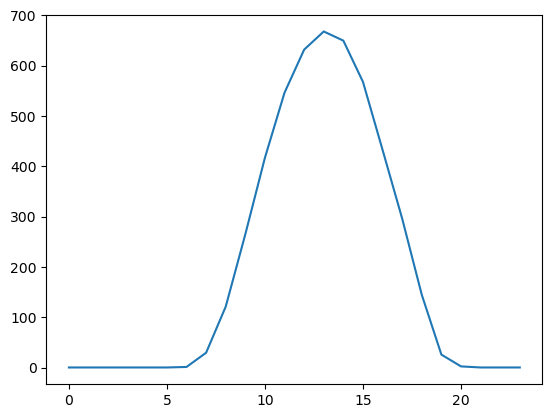

In [197]:
new_soil = soil.copy()
new_soil['year'] = soil['Date'].dt.year
new_soil['month'] = soil['Date'].dt.month
new_soil['day'] = soil['Date'].dt.day
new_soil['hour'] = soil['Date'].dt.hour
avg_srad_per_hour = new_soil.groupby('hour')['Srad'].mean()
plt.plot([i for i in range(24)], avg_srad_per_hour.values)

In [199]:
avg_srad_per_hour

hour
0       0.192245
1       0.195118
2       0.195765
3       0.196635
4       0.197410
5       0.193883
6       1.229312
7      29.509055
8     121.134849
9     265.009851
10    417.051915
11    546.350705
12    631.785731
13    667.853427
14    649.641724
15    567.726540
16    432.603133
17    296.011057
18    144.655508
19     25.786051
20      2.336324
21      0.193021
22      0.187385
23      0.191094
Name: Srad, dtype: float64

### Short Gaps in Srad
We define short gaps here by less than 24 hours. Since the seasonality is tied so strongly to day and night cycles, we locate a peak in the data around 1:00 PM (fixing it with relevant averages if it is missing) and draw a line from the last hour we have to our missing point. If this is functions well enough, we can leave it. If not, we can create a more complicated function that creates a quadratic function to see if that improves our data as the chart of averages shows a distinctly quadratic shape.  

In [208]:
# function assumes this is a shortgap over the course of a day, functions for longer gaps can utilize this one
# as the function doesn't actually depend on any of the values within the given day having data
# takes dataframe df, string column, and missing date, gives back dataframe with missing values filled in
def short_gap_fill_srad(df, column, date): 
    new_df = df.copy()
    new_df['year'] = df['Date'].dt.year
    new_df['month'] = df['Date'].dt.month
    new_df['day'] = df['Date'].dt.day
    new_df['hour'] = df['Date'].dt.hour

    new_date = pd.Series([date])
    year = int(new_date.dt.year.iloc[0])
    month = int(new_date.dt.month.iloc[0])
    day = int(new_date.dt.day.iloc[0])
    hour = int(new_date.dt.hour.iloc[0])

    slice = new_df[(new_df['day'] == day) & (new_df['month'] == month) & (new_df['year'] == year)].reset_index()

    # check if the data for 1:00 is there, substitute average from previous years in the same month if not
    if slice.loc[13, column].isna():
        avg = df[(df['month'] == month) & (df['hour'] == 13)][column].mean()
        slice.loc[13, column] = avg

    # iterate over the dataframe for the given day and fill all gaps
    i = 0
    while i < 24: 
        if slice.loc[i, column].isna():
            if i < 6: # this is a placeholder for the hour of sunrise, it can be adjusted later
                slice.loc[i, column] = 0.2 # this is a placeholder for the amount of solar radiation before sunrise
                i += 1
            elif i > 20: # this value and the one directly below operate similarly to the ones above except in regards to sunset
                slice.loc[i, column] = 0.2
                i += 1
            else: 
                j = i
                while slice.loc[j, column].isna() and j < 13: # find the next filled value to draw a line through
                    j += 1

                # draw a line from the first value before a missing value to the next filled value
                x1, y1 = i, slice.loc[i - 1, column]
                x2, y2 = j, slice.loc[j, column]
                m = (y2 - y1)/(x2 - x1)

                # fill in the line
                for k in range(i + 1, j):
                    val = slice.loc[k - 1, column] + m
                    slice.loc[k, column] = val

                i = j 

    # incorporate slice into dataframe
    new_df.loc[(new_df['day'] == day) & (new_df['month'] == month) & (new_df['year'] == year)] = slice
    new_df.reset_index()
    return new_df

#### Window/Lag Data

In [229]:
# X is n x m matrix and Y is n x 1
# window is n + 1
def offset_regression(df, column, window): 
    l = [[] for i in range(window)]

    start = 0
    final = window
    while final < df.shape[0]:
        for i in range(start, final + 1):
            if final > df.shape[0]:
                continue
            l[i % window].append(df.iloc[i][column])
        start += 1
        final += 1

    X = pd.DataFrame(data = l[:-1], columns = [i for i in range(window)])
    Y = pd.DataFrame(data = l[-1])
    return X, Y
df = soil.iloc[:25]
column = 'Srad'
window = 5

X, Y = offset_regression(df, column, window)
X

ValueError: 5 columns passed, passed data had 24 columns

In [221]:
df

,Date,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,2015-01-01 00:00:00,0.00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,0.000,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
1,2015-01-01 01:00:00,0.00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,0.000,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2,2015-01-01 02:00:00,0.00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,0.000,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
3,2015-01-01 03:00:00,0.00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,0.000,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
4,2015-01-01 04:00:00,0.00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,0.000,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105
5,2015-01-01 05:00:00,0.00,0.139,0.178,0.148,0.152,2.89,4.30,5.54,10.32,0.000,-1.450,96.5,1.035,46.66,0.39,30.3989,-98.6105
6,2015-01-01 06:00:00,0.00,0.139,0.178,0.148,0.152,2.73,4.25,5.51,10.27,0.000,-1.623,97.5,1.128,44.23,0.00,30.3989,-98.6105
7,2015-01-01 07:00:00,0.00,0.139,0.177,0.148,0.152,2.64,4.18,5.46,10.22,0.000,-1.532,97.8,0.818,55.48,0.01,30.3989,-98.6105
8,2015-01-01 08:00:00,0.00,0.139,0.177,0.148,0.152,2.64,4.11,5.39,10.17,0.000,-1.371,98.2,0.595,49.05,1.66,30.3989,-98.6105
9,2015-01-01 09:00:00,0.00,0.139,0.177,0.148,0.152,2.67,4.07,5.34,10.12,0.000,-1.191,98.7,0.821,61.78,15.86,30.3989,-98.6105
